# Compare MDP solvers

Three small MDPs, four algorithms, one shared accuracy target.

| Model | States / actions | Structure |
| --- | --- | --- |
| Garnet | 200 / 10 | Random transitions and rewards |
| Chain Walk | 100 / 2 | Stochastic movement along a chain |
| Rooms | 100 / 4 | Navigation through four connected rooms |

**Solvers:** VI (reference), PI, MPI and Aggregated VI. All use NumPy/SciPy;
no external solver backend is needed.

Use a Python 3.11+ kernel with mdpforge installed. From the repository root:

```sh
python -m pip install -e ".[notebooks]"
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from mdpforge import Benchmark
from mdpforge.solvers import aggregated_vi, mdpforge_mpi, mdpforge_pi

DISCOUNT = 0.99
PRECISION = 1e-3
REPEATS = 3
SEED = 0

np.random.seed(SEED)
bench = Benchmark()  # Includes VI as the reference.
for name in ("garnet", "chain_walk", "rooms"):
    bench.add_mdp(name)

for label, solver in {
    "PI": mdpforge_pi.Solver,
    "MPI": mdpforge_mpi.Solver,
    "Aggregated VI": aggregated_vi.Solver,
}.items():
    bench.add_solver(label, solve_function=solver)

## Run at fixed accuracy

Each solver receives a separate model copy with paired trial seeds. Runtime
includes solver construction and execution. The benchmark independently checks
$\|TV-V\|_\infty / (1-\gamma) \leq \varepsilon$, an upper bound on value error.
Catalogue models reuse cached matrices when available.

In [2]:
results = pd.DataFrame(
    bench.run(discount=DISCOUNT, precision=PRECISION, repeats=REPEATS, seed=SEED)
)
summary = results.groupby(["model", "solver"], sort=False).agg(
    median_runtime_s=("runtime", "median"),
    max_error_bound=("error_bound", "max"),
    successful_trials=("status", lambda status: status.eq("success").sum()),
)
display(summary.style.format({"median_runtime_s": "{:.4f}", "max_error_bound": "{:.2e}"}))

failures = results.loc[
    results["status"].ne("success"), ["model", "solver", "repeat", "status", "error"]
]
if not failures.empty:
    display(failures)

## Compare speed

**Speedup = median VI runtime / median solver runtime.** Above 1 is faster than
VI; below 1 is slower. `FAIL` means at least one trial failed or missed the
accuracy target. Timings depend on hardware and these small instances do not
establish a universal ranking.

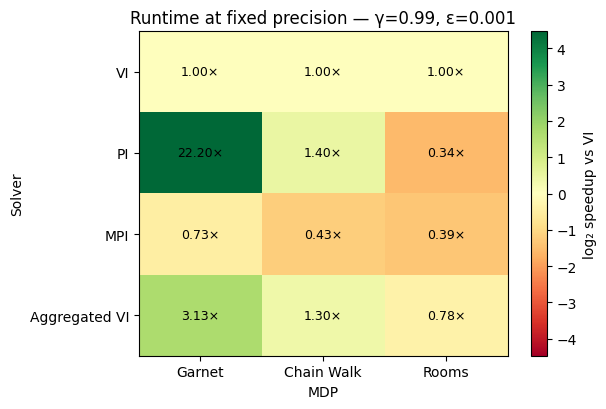

In [3]:
figure, axes = bench.plot_heat(reference="VI", show=False)
axes.set_xticks(range(3), ["Garnet", "Chain Walk", "Rooms"], rotation=0, ha="center")
figure.tight_layout()
display(figure)
plt.close(figure)

## Keep the measurements

The CSV contains every trial, including its runtime, error bound and status.
To try another comparison, edit the model and solver selections above and rerun
from the setup cell.

In [4]:
csv_path = bench.export_csv("artifacts/results/benchmark_demo.csv")
print(f"Saved {len(results)} trials to {csv_path}")

Saved 36 trials to artifacts\results\benchmark_demo.csv
